# **Project: Heart Disease Prediction using Data Mining**

**Can machine learning models predict the risk of heart disease by using the patients clinical symptoms?**

This notebook will explore the Cleveland UCI Heart Disease dataset and applies the machine learning techniques to bulit a machine learning model which can predict the heart disease using patients clinical features.

**Imports we will use in the project**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

**Loading the dataset**

Cleavland UCI Heart Disease dataset is used, containing 303 patients clinical information, The aim of this project to predict early diagnosis of heart disease.

In [4]:
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    "processed.cleveland.data",
    names=column_names
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Checking The description of our data**

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


**Data Preprocessing and cleaning**

As we can see in the previous section ca and thal coloumns are object type but not int or float type they carry values like ? which the system consider as not null values, so first we need to convert the coloumns in integer type and change the values ? into NAN

In [6]:
df["ca"].unique(), df["thal"].unique()

(array(['0.0', '3.0', '2.0', '1.0', '?'], dtype=object),
 array(['6.0', '3.0', '7.0', '?'], dtype=object))

In [7]:
df = df.replace("?", np.nan)

df["ca"] = pd.to_numeric(df["ca"], errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")

df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**Preparation of Target variable**

The target variable is converted into binary outcomes 1 and 0 indicating the presence of heart disease, will frame the task as classification problem



*   0 = no heart disease
*   1 = presence of heart disease



In [8]:
df["target_binary"] = (df["target"] > 0).astype(int)

df["target_binary"].value_counts()

,count
target_binary,
0,164
1,139


**Analysing the data**

we will perform data analysis part to identify patterns relationship and trends between heart disease outcomes and clinical features

Before training model through histogram plots will check the distribution of key numerical variables and identify the potiential outliers and check the skewness spread

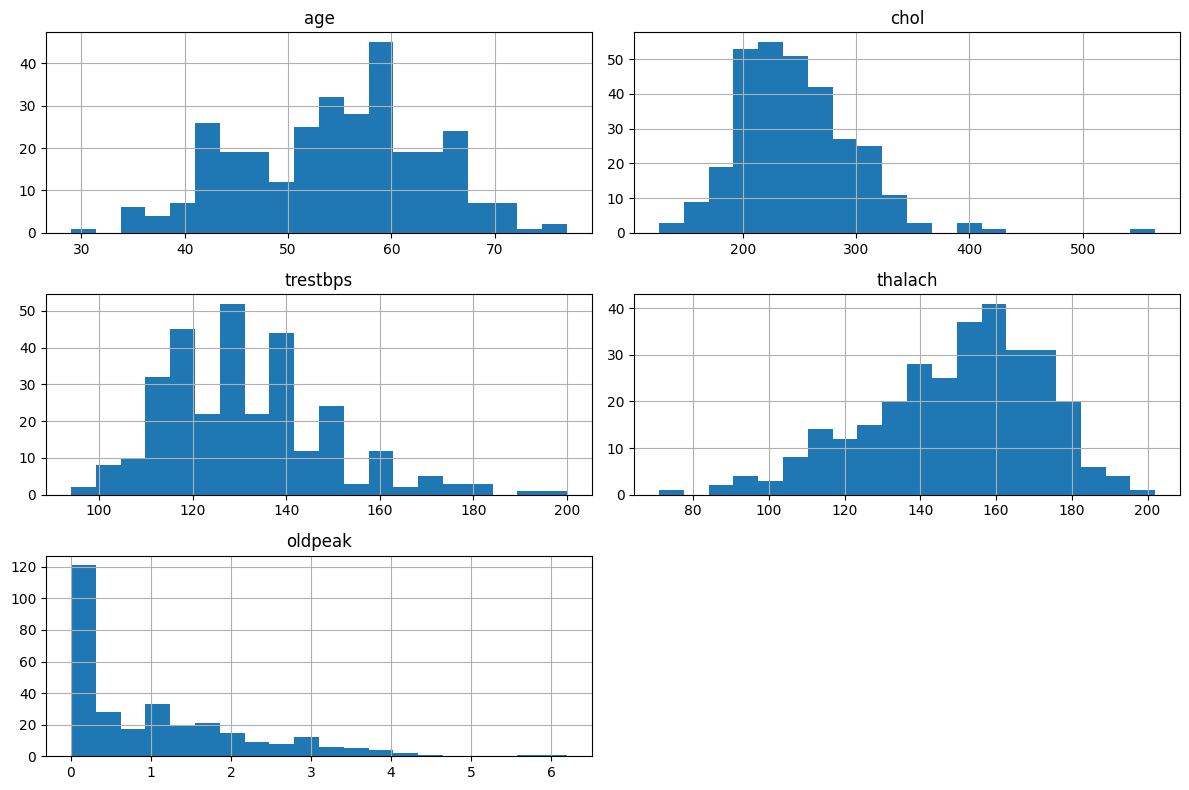

In [9]:
df[["age", "chol", "trestbps", "thalach", "oldpeak"]].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

Correlation Analysis of Clinical Features and Heart Disease to identify relationships relevant for prediction.




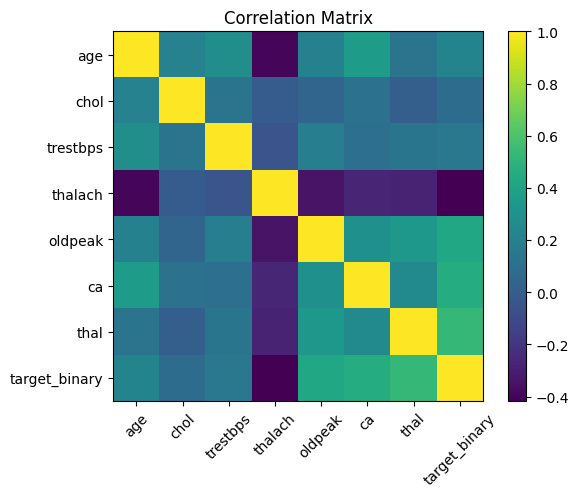

In [10]:
corr = df[["age","chol","trestbps","thalach","oldpeak","ca","thal","target_binary"]].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

**Spliting training and testing data**

In [11]:
X = df.drop(columns=["target", "target_binary"])
y = df["target_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Pre-preprocessing pipeline**

This pipeline is used to handle the missing values and feature scaling

In [12]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), X.columns)
    ]
)

**Logistic Regression Model**

At first we will train a logistic regression baseline model to predict the heart disease

In [13]:
log_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8688524590163934
Precision: 0.8125
Recall: 0.9285714285714286
F1: 0.8666666666666667


**Decision tree model**

In [14]:
tree_model = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7868852459016393


**Confusion matrix**

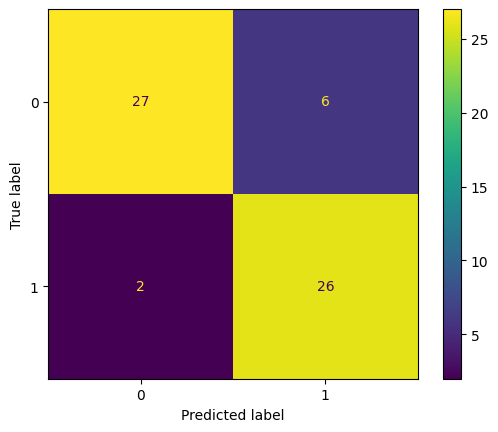

In [15]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

**Logistic Regression vs Baseline Model Performance**

In this part we will compare our logistic regression model with baseline model which traind on the most common class

In [16]:
# Baseline: always predict the most common class in the training set
majority_class = y_train.value_counts().idxmax()
y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.5409836065573771
Logistic Regression Accuracy: 0.8688524590163934


**Few examples of prediction**

The "true" coloumn is consist of orignal result and the "pred" coloumn is for predicted outputs

In [17]:
# Show a small sample of predictions
results_preview = X_test.copy()
results_preview["true"] = y_test.values
results_preview["pred"] = y_pred
results_preview["pred_prob"] = log_model.predict_proba(X_test)[:, 1]

results_preview.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,true,pred,pred_prob
219,59.0,1.0,4.0,138.0,271.0,0.0,2.0,182.0,0.0,0.0,1.0,0.0,3.0,0,0,0.217746
271,66.0,1.0,4.0,160.0,228.0,0.0,2.0,138.0,0.0,2.3,1.0,0.0,6.0,0,1,0.708639
89,51.0,0.0,3.0,130.0,256.0,0.0,2.0,149.0,0.0,0.5,1.0,0.0,3.0,0,0,0.058318
101,34.0,1.0,1.0,118.0,182.0,0.0,2.0,174.0,0.0,0.0,1.0,0.0,3.0,0,0,0.036846
67,54.0,1.0,3.0,150.0,232.0,0.0,2.0,165.0,0.0,1.6,1.0,0.0,7.0,0,1,0.536394
244,60.0,0.0,3.0,120.0,178.0,1.0,0.0,96.0,0.0,0.0,1.0,0.0,3.0,0,0,0.024224
185,63.0,0.0,2.0,140.0,195.0,0.0,0.0,179.0,0.0,0.0,1.0,2.0,3.0,0,0,0.119507
233,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,0,0,0.220526
168,35.0,1.0,4.0,126.0,282.0,0.0,2.0,156.0,1.0,0.0,1.0,0.0,7.0,1,1,0.808633
197,45.0,0.0,4.0,138.0,236.0,0.0,2.0,152.0,1.0,0.2,2.0,0.0,3.0,0,0,0.313612
